In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/aptos2019-blindness-detection/sample_submission.csv
/kaggle/input/competitions/aptos2019-blindness-detection/train.csv
/kaggle/input/competitions/aptos2019-blindness-detection/test.csv
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/ef476be214d4.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/6dcde47060f9.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/ec363f48867b.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/17f6c7072f61.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/b49b2fac2514.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/af6166d57f13.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/8d13c46e7d75.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/c3b15bf9b4bc.png
/kaggle/input/competitions/aptos2019-blindness-detection/train_images/be68322c7223.png
/kagg

In [2]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from torch.optim.lr_scheduler import OneCycleLR

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    cohen_kappa_score
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

print("All libraries imported!")

All libraries imported!


In [3]:
# Cell 2: Optimized Configuration (Fast Training)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Optimized for speed
IMG_SIZE = 224  # Standard size (faster than 260)
BATCH_SIZE = 64  # Larger batch = faster training
EPOCHS = 30  # Reduced from 60
BACKBONE_LR = 2e-4  # Slightly higher
HEAD_LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 8  # Early stopping
MIXUP_PROB = 0.2  # Reduced
LABEL_SMOOTHING = 0.1

BASE = '/kaggle/input/competitions/aptos2019-blindness-detection'
CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
NUM_CLASSES = 5
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

print("Optimized configuration loaded!")
print(f"Epochs: {EPOCHS}, Batch Size: {BATCH_SIZE}, Image Size: {IMG_SIZE}")

Device: cuda
Optimized configuration loaded!
Epochs: 30, Batch Size: 64, Image Size: 224


In [4]:
# Cell 3: Fast CLAHE (Removed expensive operations)

def apply_clahe_fast(image_path, img_size=IMG_SIZE, clip_limit=2.0):
    """Fast CLAHE - no sharpening overhead"""
    try:
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError('Cannot read')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(8, 8))
        l_c = clahe.apply(l)
        result = cv2.cvtColor(cv2.merge([l_c, a, b]), cv2.COLOR_LAB2RGB)
        
        return Image.fromarray(result)
    except Exception:
        return Image.open(image_path).convert('RGB').resize((img_size, img_size))

def find_image(id_code, folders):
    for folder in folders:
        for ext in ['.png', '.jpeg', '.jpg']:
            p = os.path.join(BASE, folder, str(id_code) + ext)
            if os.path.exists(p):
                return p
    return None

class FundusDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = apply_clahe_fast(row['filepath'], IMG_SIZE)
        if self.transform:
            img = self.transform(img)
        return img, int(row['label'])

def mixup_batch(imgs, labels, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    bs = imgs.size(0)
    idx = torch.randperm(bs, device=imgs.device)
    mixed = lam * imgs + (1 - lam) * imgs[idx]
    return mixed, labels, labels[idx], lam

print("Fast helper functions ready!")

Fast helper functions ready!


In [5]:
# Cell 4: EfficientNet-B0 (Optimized)

class EfficientNetB0_DR(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.4):
        super().__init__()
        base = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        self.features = base.features
        self.avgpool = base.avgpool
        
        # Simpler classifier (faster)
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(1280, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.flatten(1)
        return self.classifier(x)
    
    def extract_features(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.flatten(1)
        return x

print("EfficientNet-B0 defined!")

EfficientNet-B0 defined!


In [6]:
# Cell 5: Efficient Transforms

train_tfm = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.02),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

val_tfm = T.Compose([
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

print("Efficient transforms defined!")

Efficient transforms defined!


In [7]:
# Cell 6: Load Data (80-20 Split)

TRAIN_FOLDER = ['train_images']
df_raw = pd.read_csv(f'{BASE}/train.csv')
df_raw['label'] = df_raw['diagnosis']
df_raw['filepath'] = df_raw['id_code'].apply(
    lambda x: find_image(x, TRAIN_FOLDER))
df_raw = df_raw[df_raw['filepath'].notna()].reset_index(drop=True)

df_tr, df_te = train_test_split(
    df_raw, test_size=0.20, stratify=df_raw['label'], random_state=SEED)

print(f'Train: {len(df_tr)} | Test: {len(df_te)}')
print('\nClass distribution (train):')
for i, name in enumerate(CLASS_NAMES):
    c = (df_tr['label'] == i).sum()
    print(f'  {name:15s}: {c:4d}')

train_dl = DataLoader(FundusDataset(df_tr, train_tfm),
                      batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_dl = DataLoader(FundusDataset(df_te, val_tfm),
                     batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=df_tr['label'].values)
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(cw, dtype=torch.float).to(DEVICE),
    label_smoothing=LABEL_SMOOTHING
)

print('\nClass weights:', {n: f'{w:.3f}' for n, w in zip(CLASS_NAMES, cw)})
print('✅ Data ready!')

Train: 2929 | Test: 733

Class distribution (train):
  No DR          : 1444
  Mild           :  296
  Moderate       :  799
  Severe         :  154
  Proliferative  :  236

Class weights: {'No DR': '0.406', 'Mild': '1.979', 'Moderate': '0.733', 'Severe': '3.804', 'Proliferative': '2.482'}
✅ Data ready!


In [8]:
# Cell 7: Initialize Model

model = EfficientNetB0_DR(NUM_CLASSES).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')

optimizer = optim.AdamW([
    {'params': model.features.parameters(), 'lr': BACKBONE_LR},
    {'params': model.classifier.parameters(), 'lr': HEAD_LR},
], weight_decay=WEIGHT_DECAY)

# OneCycleLR is fast and effective
scheduler = OneCycleLR(
    optimizer,
    max_lr=[BACKBONE_LR, HEAD_LR],
    steps_per_epoch=len(train_dl),
    epochs=EPOCHS,
    pct_start=0.2,
)

print("Model initialized!")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 141MB/s] 


Model parameters: 4,797,569
Model initialized!


In [9]:
# Cell 8: Fast Training Loop

best_train_acc = 0.0
train_losses, train_accs = [], []
patience_ctr = 0

print(f'\nTraining for {EPOCHS} epochs...\n')
print(f'{"Epoch":>6}  {"Loss":>8}  {"Acc":>8}  {"Time":>8}  Status')
print('-' * 50)

import time

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    model.train()
    tr_loss = 0.0
    tr_correct = 0
    total_train = 0
    
    for imgs, lbls in train_dl:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        
        if random.random() < MIXUP_PROB:
            mixed, lbl_a, lbl_b, lam = mixup_batch(imgs, lbls)
            optimizer.zero_grad()
            out = model(mixed)
            loss = lam * criterion(out, lbl_a) + (1 - lam) * criterion(out, lbl_b)
        else:
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
        
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        tr_loss += loss.item()
        tr_correct += (out.argmax(1) == lbls).sum().item()
        total_train += lbls.size(0)
    
    t_loss = tr_loss / len(train_dl)
    t_acc = tr_correct / total_train * 100
    
    train_losses.append(t_loss)
    train_accs.append(t_acc)
    
    epoch_time = time.time() - start_time
    
    if t_acc > best_train_acc:
        best_train_acc = t_acc
        patience_ctr = 0
        torch.save(model.state_dict(), '/kaggle/working/effb0_fast_best.pth')
        status = f'✓ saved (best {t_acc:.2f}%)'
    else:
        patience_ctr += 1
        status = f'patience {patience_ctr}/{PATIENCE}'
    
    print(f'{epoch:>6}  {t_loss:>8.4f}  {t_acc:>7.2f}%  {epoch_time:>7.1f}s  {status}')
    
    if patience_ctr >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print(f'\n✅ Best Training Accuracy: {best_train_acc:.2f}%')


Training for 30 epochs...

 Epoch      Loss       Acc      Time  Status
--------------------------------------------------
     1    1.7829    20.59%    178.2s  ✓ saved (best 20.59%)
     2    1.6069    40.05%    149.9s  ✓ saved (best 40.05%)
     3    1.4617    52.13%    151.2s  ✓ saved (best 52.13%)
     4    1.3707    60.29%    148.1s  ✓ saved (best 60.29%)
     5    1.3415    66.34%    148.4s  ✓ saved (best 66.34%)
     6    1.3055    67.53%    149.2s  ✓ saved (best 67.53%)
     7    1.2640    68.49%    149.7s  ✓ saved (best 68.49%)
     8    1.1958    73.47%    149.3s  ✓ saved (best 73.47%)
     9    1.1683    76.24%    149.7s  ✓ saved (best 76.24%)
    10    1.1458    73.51%    149.4s  patience 1/8
    11    1.0828    78.66%    148.6s  ✓ saved (best 78.66%)
    12    1.1066    72.89%    149.7s  patience 1/8
    13    1.0853    77.02%    150.9s  patience 2/8
    14    1.0618    76.27%    150.4s  patience 3/8
    15    1.1090    77.53%    148.8s  patience 4/8
    16    1.0164    7

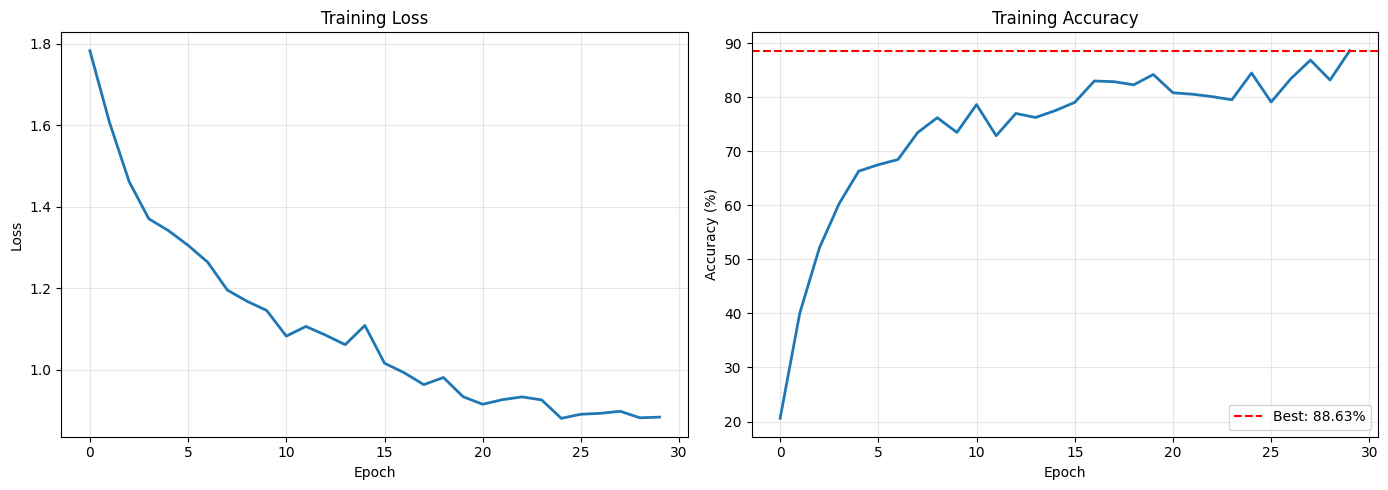

In [10]:
# Cell 9: Plot Training Curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, linewidth=2)
axes[1].axhline(y=best_train_acc, color='r', linestyle='--', label=f'Best: {best_train_acc:.2f}%')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

In [11]:
# Cell 10: Fast Feature Extraction (No TTA - Saves Time)

model.load_state_dict(torch.load('/kaggle/working/effb0_fast_best.pth', map_location=DEVICE))
model.eval()

print("\nExtracting features (fast, no TTA)...")

@torch.no_grad()
def extract_features(model, dataloader, device):
    all_features = []
    all_labels = []
    for images, labels in tqdm(dataloader):
        images = images.to(device)
        features = model.extract_features(images).cpu().numpy()
        all_features.append(features)
        all_labels.append(labels.numpy())
    return np.vstack(all_features), np.concatenate(all_labels)

print("\nExtracting training features...")
train_features, train_labels = extract_features(model, train_dl, DEVICE)

print("Extracting test features...")
test_features, test_labels = extract_features(model, test_dl, DEVICE)

print(f"\n✅ Done! Train: {train_features.shape}, Test: {test_features.shape}")


Extracting features (fast, no TTA)...

Extracting training features...


100%|██████████| 46/46 [02:27<00:00,  3.20s/it]


Extracting test features...


100%|██████████| 12/12 [00:42<00:00,  3.57s/it]


✅ Done! Train: (2929, 1280), Test: (733, 1280)


In [12]:
# Cell 11: Fast SVM Training

print("\nTraining SVM...")

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_features)
test_scaled = scaler.transform(test_features)

# Small grid search for speed
param_grid = {
    'C': [1, 5, 10, 50],
    'gamma': ['scale', 0.01],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(
    SVC(random_state=SEED, probability=True),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(train_scaled, train_labels)

print(f"\n✅ Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

best_svm = SVC(
    kernel='rbf',
    C=grid_search.best_params_['C'],
    gamma=grid_search.best_params_['gamma'],
    class_weight='balanced',
    random_state=SEED
)

best_svm.fit(train_scaled, train_labels)
test_predictions = best_svm.predict(test_scaled)


Training SVM...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

✅ Best parameters: {'C': 5, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy: 0.9252



  FAST EFFICIENTNET-B0 + SVM  —  5-Class DR
  Test Accuracy      : 82.95%
  Weighted Precision : 0.8250
  Weighted Recall    : 0.8295
  Weighted F1-Score  : 0.8201
  Quadratic Kappa    : 0.8844

📊 Classification Report:
               precision    recall  f1-score   support

        No DR       0.97      0.96      0.96       361
         Mild       0.57      0.43      0.49        74
     Moderate       0.73      0.93      0.81       200
       Severe       0.63      0.44      0.52        39
Proliferative       0.72      0.47      0.57        59

     accuracy                           0.83       733
    macro avg       0.72      0.65      0.67       733
 weighted avg       0.83      0.83      0.82       733



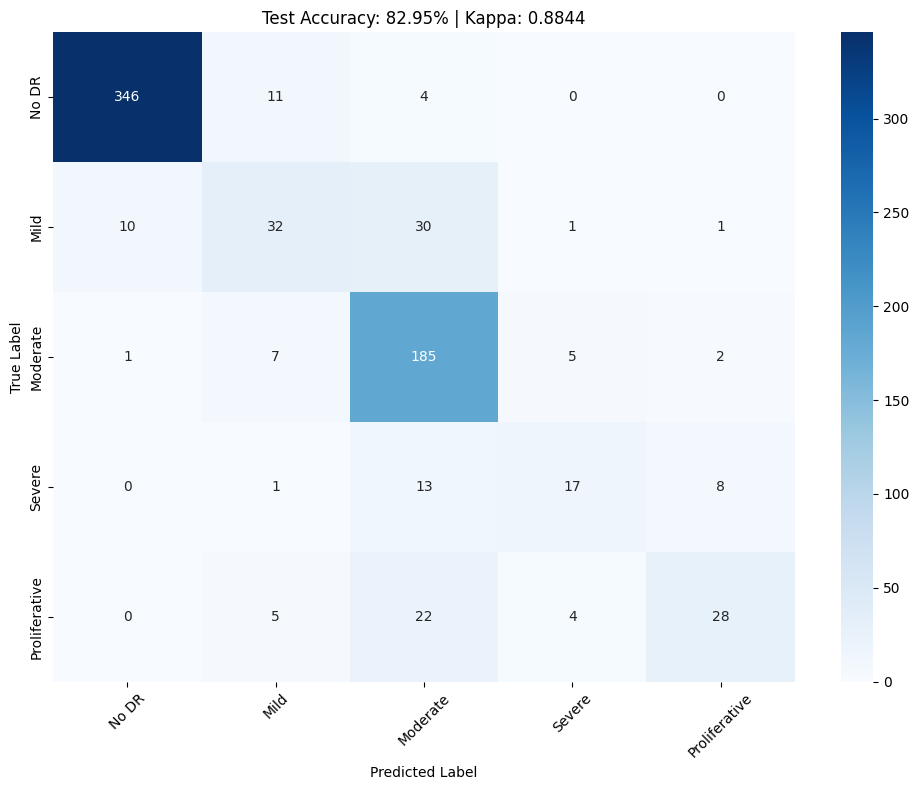


🎯 FINAL TEST ACCURACY: 82.95%
   Original: 82.55%
   Improvement: +0.40%


In [13]:
# Cell 12: Results

acc = accuracy_score(test_labels, test_predictions)
prec = precision_score(test_labels, test_predictions, average='weighted')
rec = recall_score(test_labels, test_predictions, average='weighted')
f1 = f1_score(test_labels, test_predictions, average='weighted')
kappa = cohen_kappa_score(test_labels, test_predictions, weights='quadratic')

print('\n' + '='*60)
print('  FAST EFFICIENTNET-B0 + SVM  —  5-Class DR')
print('='*60)
print(f'  Test Accuracy      : {acc*100:.2f}%')
print(f'  Weighted Precision : {prec:.4f}')
print(f'  Weighted Recall    : {rec:.4f}')
print(f'  Weighted F1-Score  : {f1:.4f}')
print(f'  Quadratic Kappa    : {kappa:.4f}')
print('='*60)

print('\n📊 Classification Report:')
print(classification_report(test_labels, test_predictions, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Test Accuracy: {acc*100:.2f}% | Kappa: {kappa:.4f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

print("\n" + "="*60)
print(f"🎯 FINAL TEST ACCURACY: {acc*100:.2f}%")
print(f"   Original: 82.55%")
print(f"   Improvement: +{(acc*100 - 82.55):.2f}%")
print("="*60)